In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# 0) Install (optional) and imports
# ============================================================
# In Kaggle, many packages are already available. Uncomment if needed:
# !pip -q install pydot graphviz

import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow import keras
from tensorflow.keras import layers, regularizers

print("TensorFlow:", tf.__version__)

# Mixed precision for Kaggle GPU
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")
except Exception as e:
    print("Mixed precision not enabled:", e)

# ============================================================
# 1) Reproducibility
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 5

2026-04-30 19:32:28.254277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777577548.654234      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777577548.773530      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777577549.762330      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777577549.762377      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777577549.762381      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Mixed precision enabled.


In [2]:
# ============================================================
# 2) Paths
# ============================================================
DATA_DIR = "/kaggle/input/competitions/cassava-leaf-disease-classification"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "sample_submission.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMG_DIR = os.path.join(DATA_DIR, "test_images")

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, "plots"), exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, "models"), exist_ok=True)

CLASS_NAMES = [
    "Cassava Bacterial Blight",
    "Cassava Brown Streak Disease",
    "Cassava Green Mottle Disease",
    "Cassava Mosaic Disease",
    "Healthy"
]

In [15]:
# ============================================================
# 3) Load data
# ============================================================
df = pd.read_csv(TRAIN_CSV)

# Kaggle competition train.csv uses image_id and label
df["filepath"] = df["image_id"].apply(lambda x: os.path.join(TRAIN_IMG_DIR, x))
df["label"] = df["label"].astype("int32")

print(df.head())
print("Shape:", df.shape)
print(df["label"].value_counts().sort_index())


         image_id  label                                           filepath
0  1000015157.jpg      0  /kaggle/input/competitions/cassava-leaf-diseas...
1  1000201771.jpg      3  /kaggle/input/competitions/cassava-leaf-diseas...
2   100042118.jpg      1  /kaggle/input/competitions/cassava-leaf-diseas...
3  1000723321.jpg      1  /kaggle/input/competitions/cassava-leaf-diseas...
4  1000812911.jpg      3  /kaggle/input/competitions/cassava-leaf-diseas...
Shape: (21397, 3)
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64


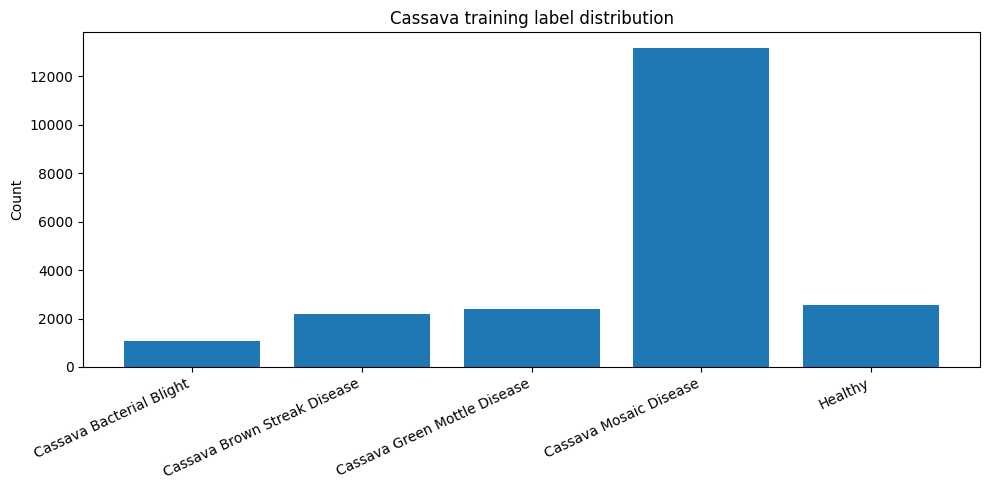

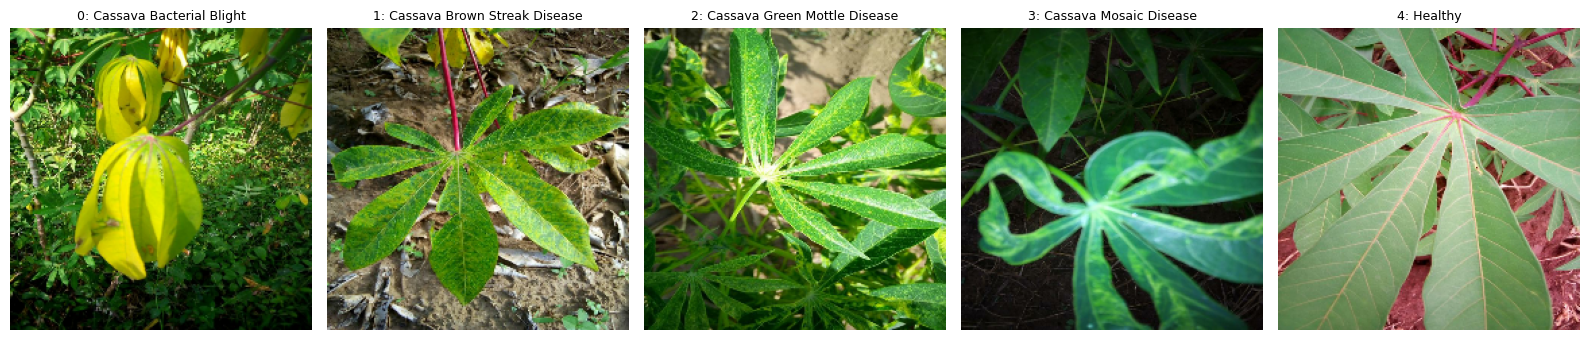

In [16]:
# ============================================================
# 4) Quick EDA
# ============================================================
def plot_label_distribution(dataframe, title="Class distribution"):
    counts = dataframe["label"].value_counts().sort_index()
    labels = [CLASS_NAMES[i] for i in counts.index]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts.values)
    plt.xticks(rotation=25, ha="right")
    plt.title(title)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def show_one_image_per_class(dataframe):
    sample = dataframe.groupby("label", group_keys=False).sample(1, random_state=SEED).sort_values("label")
    plt.figure(figsize=(16, 4))
    for i, (_, row) in enumerate(sample.iterrows()):
        img = tf.io.read_file(row["filepath"])
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224)).numpy().astype(np.uint8)

        ax = plt.subplot(1, NUM_CLASSES, i + 1)
        ax.imshow(img)
        ax.set_title(f"{row['label']}: {CLASS_NAMES[row['label']]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_label_distribution(df, "Cassava training label distribution")
show_one_image_per_class(df)

In [17]:
# ============================================================
# 5) Train/validation split
# ============================================================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", train_df.shape, "Val:", val_df.shape)

Train: (17117, 3) Val: (4280, 3)


In [18]:
# ============================================================
# 6) Class weights
# ============================================================
classes = np.unique(train_df["label"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)
CLASS_WEIGHT = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", CLASS_WEIGHT)


Class weights: {0: 3.934942528735632, 1: 1.9551113649343232, 2: 1.7932949188056575, 3: 0.3252327569827095, 4: 1.6610383309073264}


In [19]:
# ============================================================
# 7) Data pipeline
# ============================================================
def load_image(path, label, img_size):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (img_size, img_size), antialias=True)
    image = tf.cast(image, tf.float32)  # keep [0,255] range for preprocessing later
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(dataframe, img_size, batch_size=32, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, img_size), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

def make_test_dataset(dataframe, img_size, batch_size=32):
    paths = dataframe["filepath"].values
    ds = tf.data.Dataset.from_tensor_slices(paths)

    def _load(path):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, (img_size, img_size), antialias=True)
        image = tf.cast(image, tf.float32)
        return image

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [20]:
# ============================================================
# 8) Augmentation
# ============================================================
augmenter = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="augmentation"
)

In [21]:
# ============================================================
# 9) Plot helpers
# ============================================================
def plot_history(history_dict, title):
    plt.figure(figsize=(12, 5))
    plt.plot(history_dict["accuracy"], label="train_accuracy")
    plt.plot(history_dict["val_accuracy"], label="val_accuracy")
    plt.plot(history_dict["loss"], label="train_loss")
    plt.plot(history_dict["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(NUM_CLASSES)
    plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, CLASS_NAMES)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.show()

def merge_histories(h1, h2):
    merged = {}
    for k, v in h1.history.items():
        merged[k] = list(v) + list(h2.history.get(k, []))
    for k, v in h2.history.items():
        if k not in merged:
            merged[k] = list(v)
    return merged

Epoch 1/8


E0000 00:00:1777578301.367003      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/baseline_cnn_2blocks_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777578303.951982     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3322 - loss: 1.5771
Epoch 1: val_accuracy improved from -inf to 0.22336, saving model to /kaggle/working/models/baseline_2blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 101s 172ms/step - accuracy: 0.3323 - loss: 1.5770 - val_accuracy: 0.2234 - val_loss: 1.5401 - learning_rate: 0.0010
Epoch 2/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4449 - loss: 1.4119
Epoch 2: val_accuracy improved from 0.22336 to 0.27430, saving model to /kaggle/working/models/baseline_2blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 80s 149ms/step - accuracy: 0.4449 - loss: 1.4119 - val_accuracy: 0.2743 - val_loss: 1.8849 - learning_rate: 0.0010
Epoch 3/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5021 - loss: 1.3577
Epoch 3: val_accuracy improved from 0.27430 to 0.34766, saving model to /kaggle/working/models/baseline_2blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 80s 150ms/step - accuracy: 0.5021 - loss: 1.3576 - val_accuracy: 

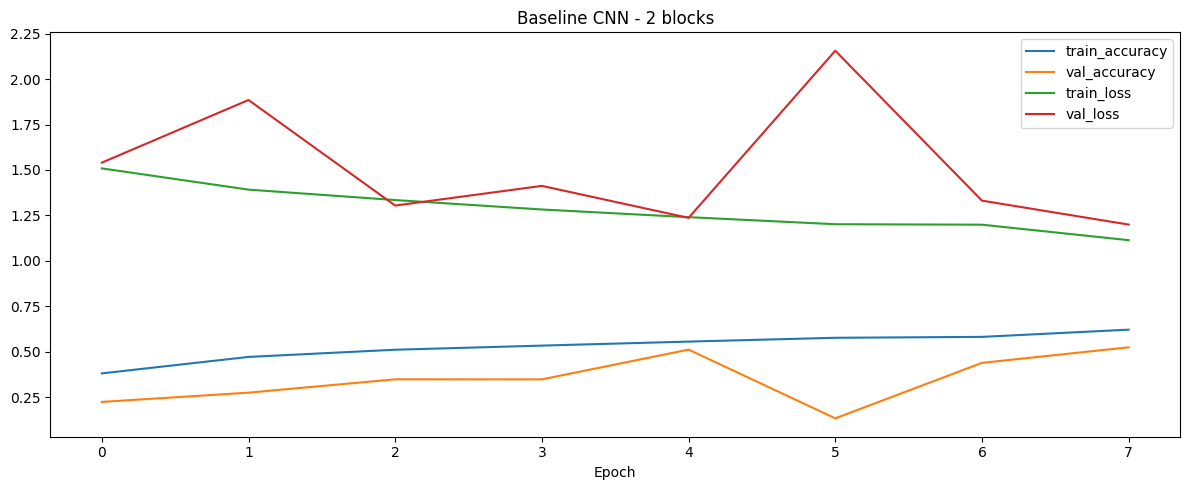

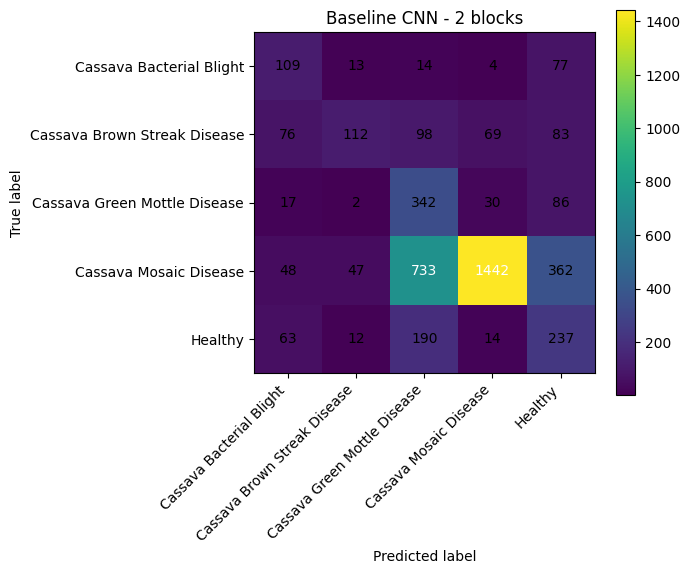

                              precision    recall  f1-score   support

    Cassava Bacterial Blight       0.35      0.50      0.41       217
Cassava Brown Streak Disease       0.60      0.26      0.36       438
Cassava Green Mottle Disease       0.25      0.72      0.37       477
      Cassava Mosaic Disease       0.92      0.55      0.69      2632
                     Healthy       0.28      0.46      0.35       516

                    accuracy                           0.52      4280
                   macro avg       0.48      0.50      0.44      4280
                weighted avg       0.71      0.52      0.56      4280

Epoch 1/8


E0000 00:00:1777578994.016427      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/baseline_cnn_3blocks_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3309 - loss: 1.6109
Epoch 1: val_accuracy improved from -inf to 0.14930, saving model to /kaggle/working/models/baseline_3blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 95s 172ms/step - accuracy: 0.3310 - loss: 1.6107 - val_accuracy: 0.1493 - val_loss: 1.9062 - learning_rate: 0.0010
Epoch 2/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4863 - loss: 1.3766
Epoch 2: val_accuracy did not improve from 0.14930
535/535 ━━━━━━━━━━━━━━━━━━━━ 91s 170ms/step - accuracy: 0.4863 - loss: 1.3765 - val_accuracy: 0.1269 - val_loss: 2.5469 - learning_rate: 0.0010
Epoch 3/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5256 - loss: 1.2939
Epoch 3: val_accuracy improved from 0.14930 to 0.56893, saving model to /kaggle/working/models/baseline_3blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 91s 170ms/step - accuracy: 0.5256 - loss: 1.2939 - val_accuracy: 0.5689 - val_loss: 1.1303 - learning_rate: 0.0010
Epoch 4/8
535/535 ━━━━━

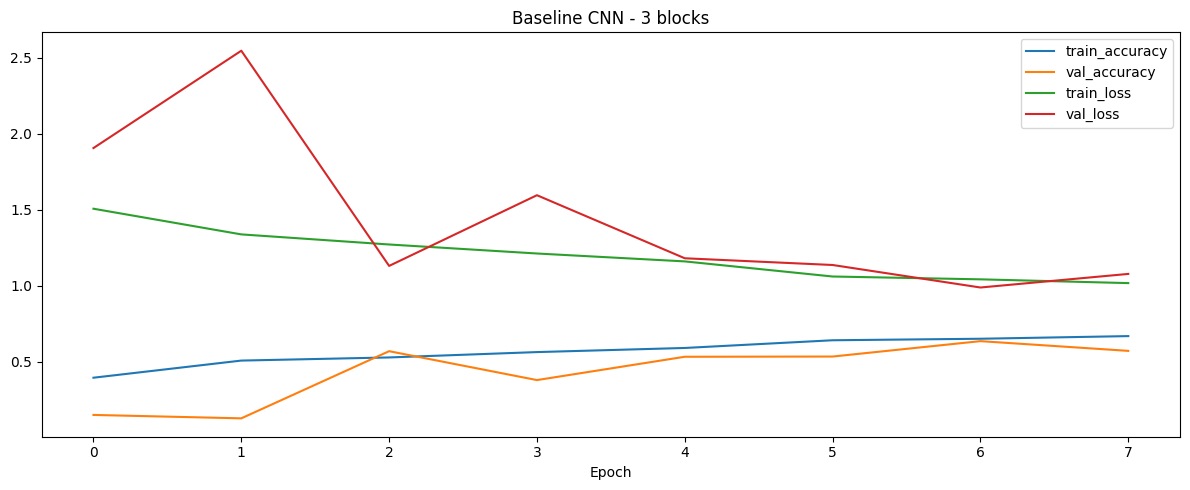

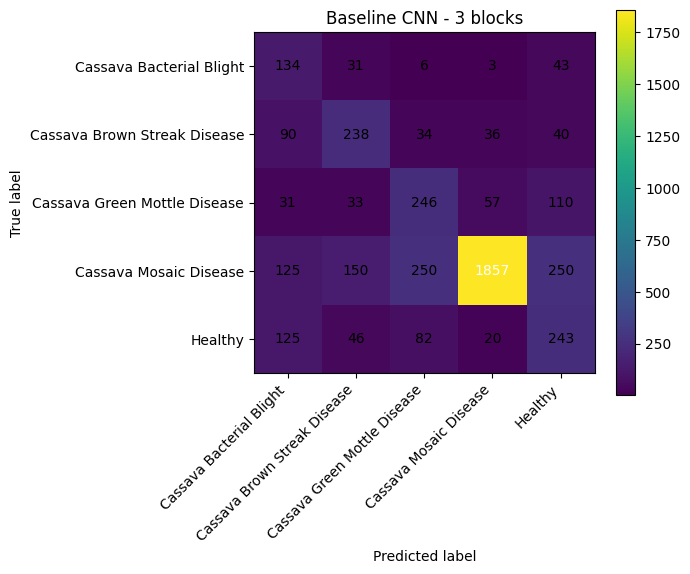

                              precision    recall  f1-score   support

    Cassava Bacterial Blight       0.27      0.62      0.37       217
Cassava Brown Streak Disease       0.48      0.54      0.51       438
Cassava Green Mottle Disease       0.40      0.52      0.45       477
      Cassava Mosaic Disease       0.94      0.71      0.81      2632
                     Healthy       0.35      0.47      0.40       516

                    accuracy                           0.64      4280
                   macro avg       0.49      0.57      0.51      4280
                weighted avg       0.73      0.64      0.67      4280

Epoch 1/8


E0000 00:00:1777579740.811477      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/baseline_cnn_4blocks_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3341 - loss: 1.6820
Epoch 1: val_accuracy improved from -inf to 0.30327, saving model to /kaggle/working/models/baseline_4blocks.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 101s 181ms/step - accuracy: 0.3342 - loss: 1.6818 - val_accuracy: 0.3033 - val_loss: 1.4434 - learning_rate: 0.0010
Epoch 2/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.4730 - loss: 1.3969
Epoch 2: val_accuracy did not improve from 0.30327
535/535 ━━━━━━━━━━━━━━━━━━━━ 96s 180ms/step - accuracy: 0.4730 - loss: 1.3969 - val_accuracy: 0.2136 - val_loss: 1.6703 - learning_rate: 0.0010
Epoch 3/8
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5113 - loss: 1.3270
Epoch 3: val_accuracy did not improve from 0.30327

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 180ms/step - accuracy: 0.5114 - loss: 1.3270 - val_accuracy: 0.2311 - val_loss: 1.6613 - learning_rate: 0.0010
Epoch 4/8
535/53

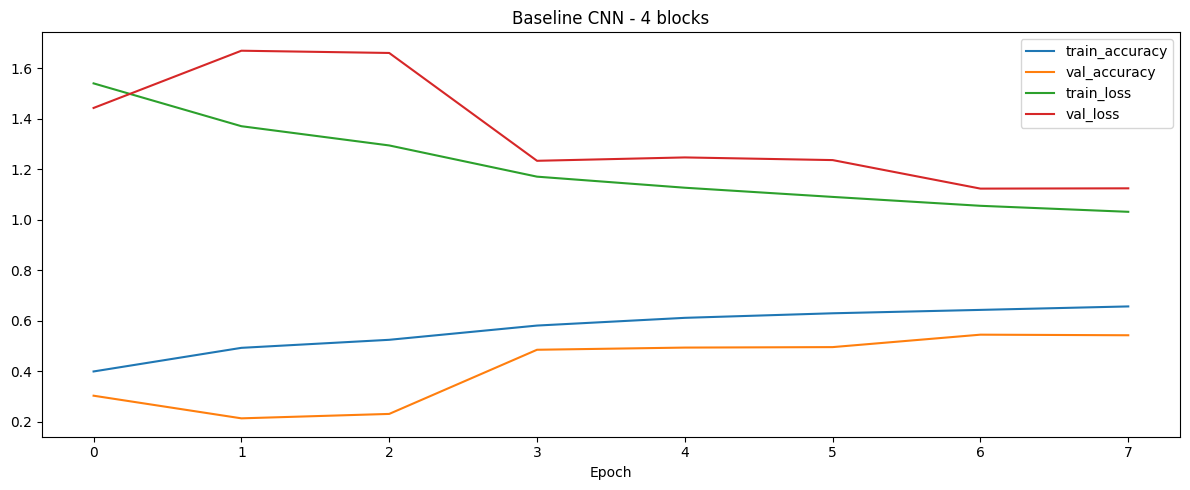

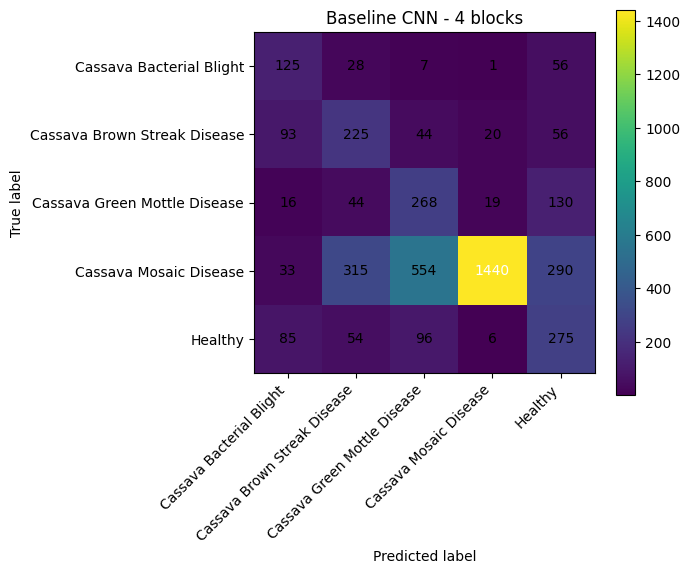

                              precision    recall  f1-score   support

    Cassava Bacterial Blight       0.36      0.58      0.44       217
Cassava Brown Streak Disease       0.34      0.51      0.41       438
Cassava Green Mottle Disease       0.28      0.56      0.37       477
      Cassava Mosaic Disease       0.97      0.55      0.70      2632
                     Healthy       0.34      0.53      0.42       516

                    accuracy                           0.55      4280
                   macro avg       0.46      0.55      0.47      4280
                weighted avg       0.72      0.55      0.59      4280

Baseline ablation results


,model,val_accuracy,val_f1_macro,params
1,Baseline_3_blocks,0.635047,0.507979,128453
2,Baseline_4_blocks,0.545093,0.466549,457413
0,Baseline_2_blocks,0.523832,0.435128,37701


In [22]:
# ============================================================
# 10) Baseline CNN
#    Use this to justify your chosen depth by comparing 2, 3, 4 blocks.
# ============================================================
def build_baseline_cnn(img_size=224, n_blocks=3, dense_units=256, dropout=0.4):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = augmenter(inputs)
    x = layers.Rescaling(1./255)(x)

    filters = [32, 64, 128, 256, 512]
    for i in range(n_blocks):
        x = layers.Conv2D(filters[i], 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.20)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name=f"baseline_cnn_{n_blocks}blocks")
    return model

# Optional baseline ablation
RUN_BASELINE_ABLATION = True
baseline_results = []

if RUN_BASELINE_ABLATION:
    for blocks in [2, 3, 4]:
        tf.keras.backend.clear_session()
        gc.collect()

        img_size = 224
        batch_size = 32
        train_ds = make_dataset(train_df, img_size, batch_size=batch_size, training=True)
        val_ds = make_dataset(val_df, img_size, batch_size=batch_size, training=False)

        model = build_baseline_cnn(img_size=img_size, n_blocks=blocks)
        model.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
        )

        ckpt = os.path.join(WORK_DIR, "models", f"baseline_{blocks}blocks.weights.h5")
        callbacks = [
            keras.callbacks.ModelCheckpoint(ckpt, save_best_only=True, save_weights_only=True, monitor="val_accuracy", verbose=1),
            keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7, verbose=1),
        ]

        hist = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=8,
            class_weight=CLASS_WEIGHT,
            callbacks=callbacks,
            verbose=1
        )

        model.load_weights(ckpt)
        val_probs = model.predict(val_ds, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)
        y_true = val_df["label"].values

        acc = accuracy_score(y_true, val_pred)
        f1 = f1_score(y_true, val_pred, average="macro")

        baseline_results.append({
            "model": f"Baseline_{blocks}_blocks",
            "val_accuracy": acc,
            "val_f1_macro": f1,
            "params": model.count_params()
        })

        plot_history(hist.history, f"Baseline CNN - {blocks} blocks")
        plot_conf_matrix(y_true, val_pred, f"Baseline CNN - {blocks} blocks")

        print(classification_report(y_true, val_pred, target_names=CLASS_NAMES))

        plot_path = os.path.join(WORK_DIR, "plots", f"baseline_{blocks}_blocks.png")
        try:
            tf.keras.utils.plot_model(
                model,
                to_file=os.path.join(WORK_DIR, "plots", f"baseline_{blocks}_blocks_diagram.png"),
                show_shapes=True,
                show_layer_names=True,
                expand_nested=True,
                dpi=120
            )
        except Exception as e:
            print("plot_model failed:", e)

        del model
        gc.collect()

baseline_results_df = pd.DataFrame(baseline_results)
if not baseline_results_df.empty:
    print("Baseline ablation results")
    display(baseline_results_df.sort_values("val_f1_macro", ascending=False))


In [36]:
# ============================================================
# 11) Transfer learning backbones
# ============================================================
MODEL_SPECS = {
    "ResNet50": {
        "builder": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet.preprocess_input,
        "img_size": 224,
        "batch_size": 32
    },
    "MobileNetV2": {
        "builder": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "img_size": 224,
        "batch_size": 32
    },
    "DenseNet121": {
        "builder": tf.keras.applications.DenseNet121,
        "preprocess": tf.keras.applications.densenet.preprocess_input,
        "img_size": 224,
        "batch_size": 32
    },
    "InceptionV3": {
        "builder": tf.keras.applications.InceptionV3,
        "preprocess": tf.keras.applications.inception_v3.preprocess_input,
        "img_size": 224,
        "batch_size": 32
    },
    "EfficientNetB0": {
        "builder": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,  # pass-through for EfficientNet
        "img_size": 224,
        "batch_size": 32
    }
}

def build_transfer_model(
    backbone_name,
    img_size,
    n_dense_layers=2,
    dense_units=256,
    dropout=0.4,
    l2_reg=1e-4
):
    spec = MODEL_SPECS[backbone_name]
    backbone_fn = spec["builder"]
    preprocess_fn = spec["preprocess"]

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = augmenter(inputs)
    x = layers.Lambda(preprocess_fn, name=f"{backbone_name}_preprocess")(x)

    base_model = backbone_fn(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    for i in range(n_dense_layers):
        x = layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f"head_dense_{i+1}"
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="classifier")(x)
    model = keras.Model(inputs, outputs, name=backbone_name)

    return model, base_model

def freeze_all_bn(model):
    for layer in model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

def unfreeze_last_n_layers(base_model, n_layers):
    base_model.trainable = True
    if n_layers <= 0:
        base_model.trainable = False
        return

    n_layers = min(n_layers, len(base_model.layers))
    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False
    for layer in base_model.layers[-n_layers:]:
        # Keep batch norm frozen during fine-tuning
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

def plot_and_save_model_diagram(model, filename):
    try:
        tf.keras.utils.plot_model(
            model,
            to_file=filename,
            show_shapes=True,
            show_layer_names=True,
            expand_nested=True,
            dpi=120
        )
    except Exception as e:
        print("plot_model failed:", e)

def train_two_stage_model(
    backbone_name,
    n_dense_layers=2,
    dense_units=256,
    dropout=0.4,
    frozen_epochs=5,
    finetune_epochs=5,
    fine_tune_last_n=40
):
    spec = MODEL_SPECS[backbone_name]
    img_size = spec["img_size"]
    batch_size = spec["batch_size"]

    train_ds = make_dataset(train_df, img_size, batch_size=batch_size, training=True)
    val_ds = make_dataset(val_df, img_size, batch_size=batch_size, training=False)

    model, base_model = build_transfer_model(
        backbone_name=backbone_name,
        img_size=img_size,
        n_dense_layers=n_dense_layers,
        dense_units=dense_units,
        dropout=dropout
    )

    # Save diagrams for report
    plot_and_save_model_diagram(
        model,
        os.path.join(WORK_DIR, "plots", f"{backbone_name}_full_model.png")
    )

    # -------------------------
    # Stage 1: feature extraction
    # -------------------------
    stage1_ckpt = os.path.join(WORK_DIR, "models", f"{backbone_name}_stage1.weights.h5")
    callbacks1 = [
        keras.callbacks.ModelCheckpoint(
            stage1_ckpt, save_best_only=True, save_weights_only=True,
            monitor="val_accuracy", verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=3, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7, verbose=1
        ),
    ]

    compile_model(model, lr=1e-3)
    hist1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=frozen_epochs,
        class_weight=CLASS_WEIGHT,
        callbacks=callbacks1,
        verbose=1
    )
    model.load_weights(stage1_ckpt)

    # -------------------------
    # Stage 2: fine-tuning
    # -------------------------
    unfreeze_last_n_layers(base_model, fine_tune_last_n)
    freeze_all_bn(base_model)

    stage2_ckpt = os.path.join(WORK_DIR, "models", f"{backbone_name}_stage2.weights.h5")
    callbacks2 = [
        keras.callbacks.ModelCheckpoint(
            stage2_ckpt, save_best_only=True, save_weights_only=True,
            monitor="val_accuracy", verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=3, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7, verbose=1
        ),
    ]

    compile_model(model, lr=1e-5)
    hist2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=finetune_epochs,
        class_weight=CLASS_WEIGHT,
        callbacks=callbacks2,
        verbose=1
    )
    model.load_weights(stage2_ckpt)

    # Evaluate
    val_probs = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)
    y_true = val_df["label"].values

    acc = accuracy_score(y_true, val_pred)
    f1 = f1_score(y_true, val_pred, average="macro")

    print(f"\n{backbone_name} => val accuracy: {acc:.4f}, val macro F1: {f1:.4f}")
    print(classification_report(y_true, val_pred, target_names=CLASS_NAMES))
    plot_conf_matrix(y_true, val_pred, f"{backbone_name} confusion matrix")

    merged_hist = merge_histories(hist1, hist2)
    plot_history(merged_hist, f"{backbone_name} training curves")

    return {
        "model_name": backbone_name,
        "model": model,
        "history": merged_hist,
        "val_accuracy": acc,
        "val_f1_macro": f1,
        "params": model.count_params(),
        "img_size": img_size,
        "batch_size": batch_size,
        "fine_tune_last_n": fine_tune_last_n,
        "n_dense_layers": n_dense_layers
    }

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4067 - loss: 1.8203
Epoch 1: val_accuracy improved from -inf to 0.45607, saving model to /kaggle/working/models/ResNet50_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 166ms/step - accuracy: 0.4069 - loss: 1.8199 - val_accuracy: 0.4561 - val_loss: 1.4737 - learning_rate: 0.0010
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5657 - loss: 1.2978
Epoch 2: val_accuracy improved from 0.45607 to 0.47009, saving model to /kaggle/working/models/ResNet50_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 88s 165ms/step - accuracy: 0.5657 - loss: 1.2977 - val_accuracy: 0.4701 - val_loss: 1.5037 - learning_rate: 0.0010
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5979 - loss: 1.1876
Epoch 3: val_accuracy improved from 0.47009 to 0.58879, saving model to /kaggle/working/models/ResNet50_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 89s 167ms/step - accuracy: 0.5979 - loss: 1.1876 - val_accu

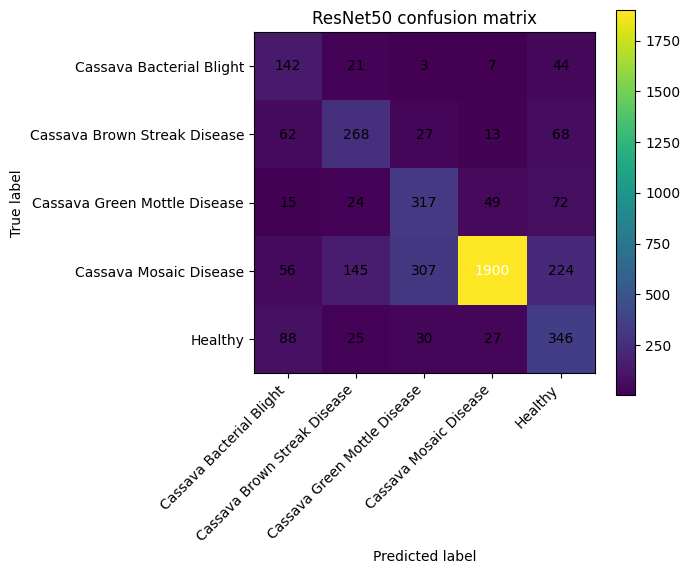

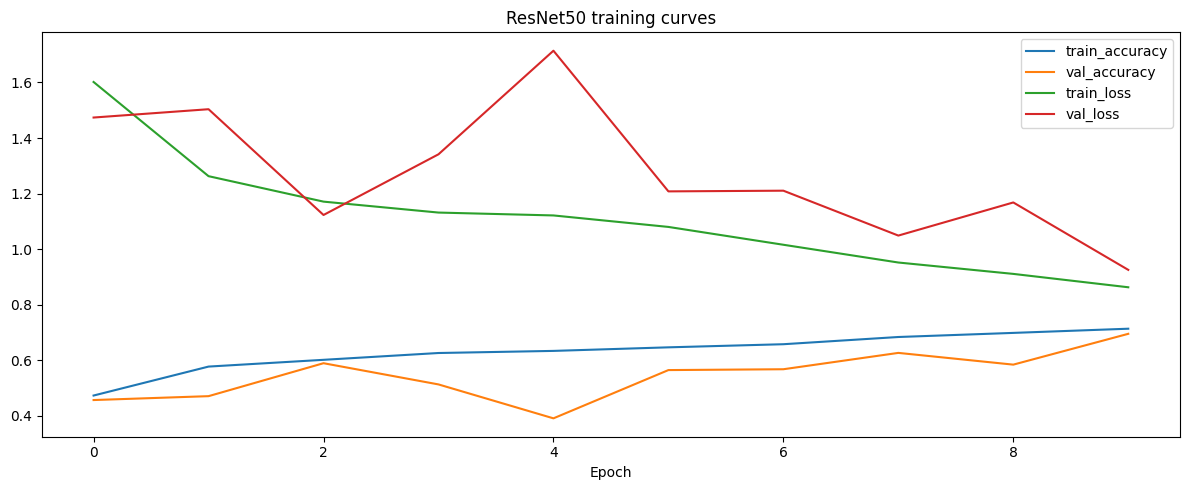

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4195 - loss: 1.7705
Epoch 1: val_accuracy improved from -inf to 0.44019, saving model to /kaggle/working/models/MobileNetV2_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 75s 128ms/step - accuracy: 0.4196 - loss: 1.7701 - val_accuracy: 0.4402 - val_loss: 1.5015 - learning_rate: 0.0010
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5517 - loss: 1.3060
Epoch 2: val_accuracy improved from 0.44019 to 0.46706, saving model to /kaggle/working/models/MobileNetV2_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - accuracy: 0.5517 - loss: 1.3059 - val_accuracy: 0.4671 - val_loss: 1.4401 - learning_rate: 0.0010
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5961 - loss: 1.1831
Epoch 3: val_accuracy improved from 0.46706 to 0.49836, saving model to /kaggle/working/models/MobileNetV2_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 66s 124ms/step - accuracy: 0.5961 - loss: 1.1831 - va

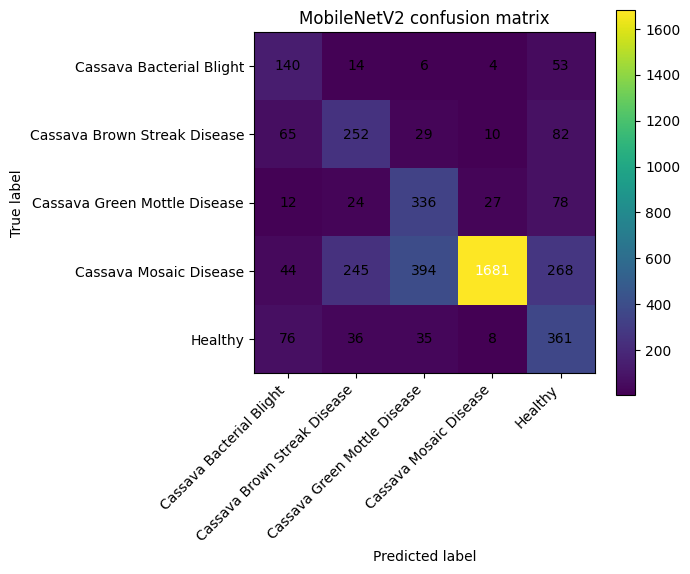

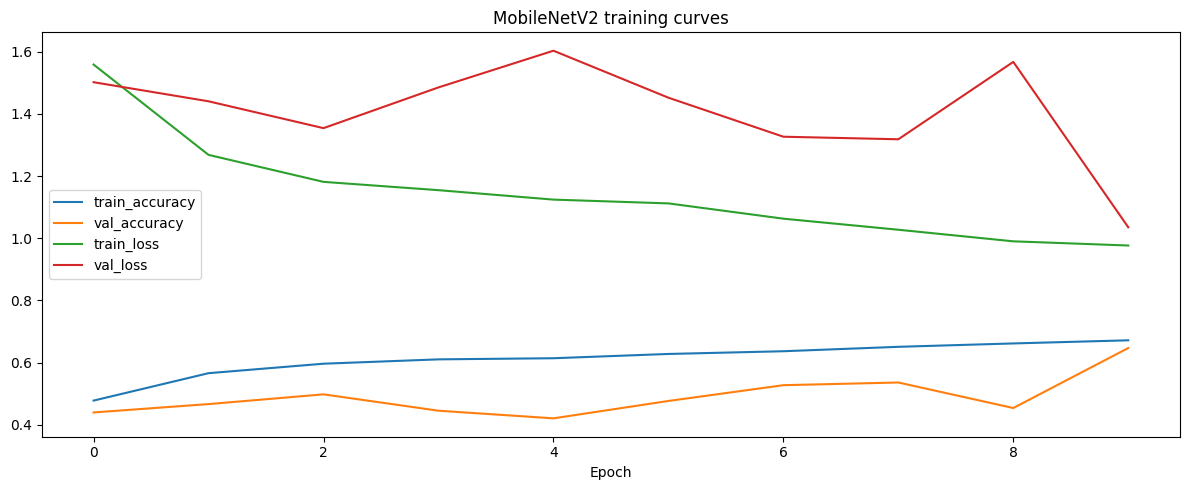

"dot" with args ['-Tpng', '/tmp/tmpp26wdwbo/tmpnr5nu74a'] returned code: -6

stdout, stderr:
 b''
b"failed at node 6076[1]\ndot: maze.c:313: chkSgraph: Assertion `np->cells[1]' failed.\n"

plot_model failed: "dot" with args ['-Tpng', '/tmp/tmpp26wdwbo/tmpnr5nu74a'] returned code: -6
Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3993 - loss: 1.8583
Epoch 1: val_accuracy improved from -inf to 0.50631, saving model to /kaggle/working/models/DenseNet121_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 113s 187ms/step - accuracy: 0.3994 - loss: 1.8578 - val_accuracy: 0.5063 - val_loss: 1.4244 - learning_rate: 0.0010
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5434 - loss: 1.3349
Epoch 2: val_accuracy improved from 0.50631 to 0.51986, saving model to /kaggle/working/models/DenseNet121_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 97s 181ms/step - accuracy: 0.5434 - loss: 1.3348 - val_accuracy: 0.5199 - val_loss: 1.3349 - learning_rate: 0.0010
Epoch 

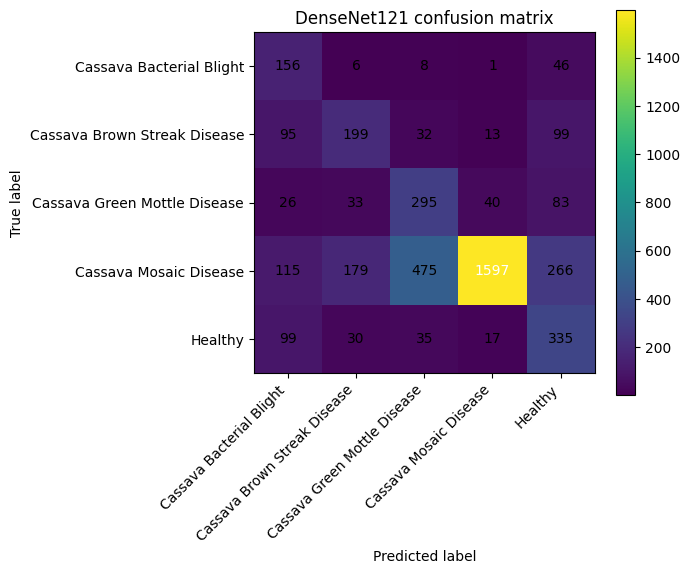

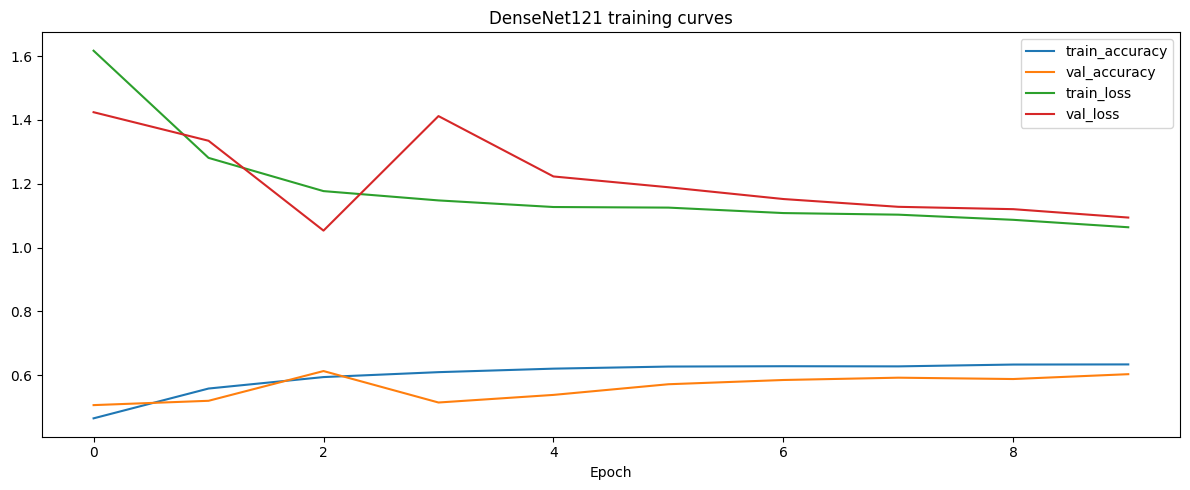

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3689 - loss: 1.9054
Epoch 1: val_accuracy improved from -inf to 0.39533, saving model to /kaggle/working/models/InceptionV3_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - accuracy: 0.3690 - loss: 1.9050 - val_accuracy: 0.3953 - val_loss: 1.6065 - learning_rate: 0.0010
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5008 - loss: 1.4153
Epoch 2: val_accuracy improved from 0.39533 to 0.46893, saving model to /kaggle/working/models/InceptionV3_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 129ms/step - accuracy: 0.5009 - loss: 1.4152 - val_accuracy: 0.4689 - val_loss: 1.4421 - learning_rate: 0.0010
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5349 - loss: 1.3265
Epoch 3: val_accuracy improved from 0.46893 to 0.52523, saving model to /kaggle/working/models/InceptionV3_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━

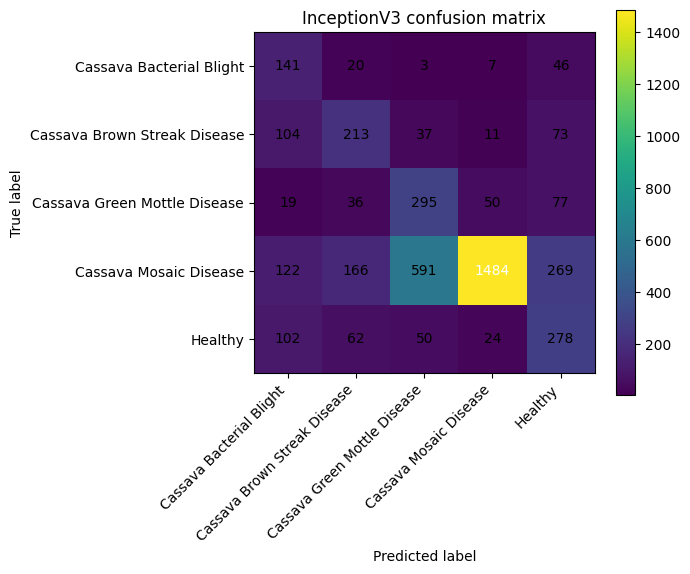

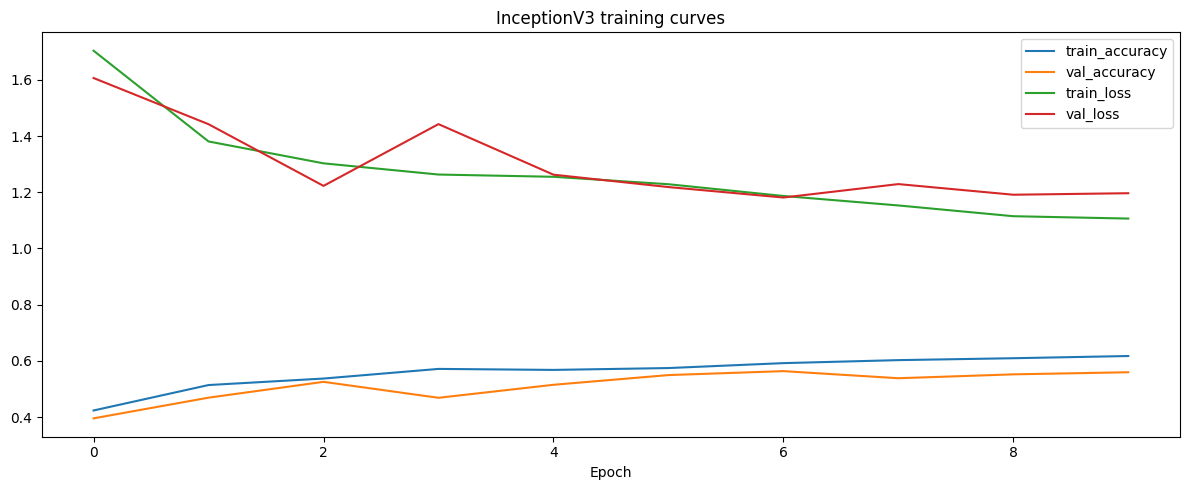

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


E0000 00:00:1777587831.820865      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4018 - loss: 1.8414
Epoch 1: val_accuracy improved from -inf to 0.55467, saving model to /kaggle/working/models/EfficientNetB0_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.4019 - loss: 1.8409 - val_accuracy: 0.5547 - val_loss: 1.2898 - learning_rate: 0.0010
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5604 - loss: 1.3206
Epoch 2: val_accuracy improved from 0.55467 to 0.64673, saving model to /kaggle/working/models/EfficientNetB0_stage1.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 128ms/step - accuracy: 0.5604 - loss: 1.3205 - val_accuracy: 0.6467 - val_loss: 1.0552 - learning_rate: 0.0010
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6158 - loss: 1.1954
Epoch 3: val_accuracy did not improve from 0.64673
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6158 - loss: 1.1954 - val_accuracy: 0.6456 - val_loss: 1.0700 - learning_rate: 0.0010
Epoch 4/5
535

E0000 00:00:1777588189.789559      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6464 - loss: 1.0901
Epoch 1: val_accuracy improved from -inf to 0.66869, saving model to /kaggle/working/models/EfficientNetB0_stage2.weights.h5
535/535 ━━━━━━━━━━━━━━━━━━━━ 85s 134ms/step - accuracy: 0.6464 - loss: 1.0901 - val_accuracy: 0.6687 - val_loss: 1.0062 - learning_rate: 1.0000e-05
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6556 - loss: 1.0787
Epoch 2: val_accuracy did not improve from 0.66869
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 128ms/step - accuracy: 0.6556 - loss: 1.0787 - val_accuracy: 0.6439 - val_loss: 1.0687 - learning_rate: 1.0000e-05
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6714 - loss: 1.0327
Epoch 3: val_accuracy did not improve from 0.66869

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 128ms/step - accuracy: 0.6714 - loss: 1.0326 - val_accuracy: 0.6643 - val_loss: 1.0246 - learning_rate: 1.0000e-05


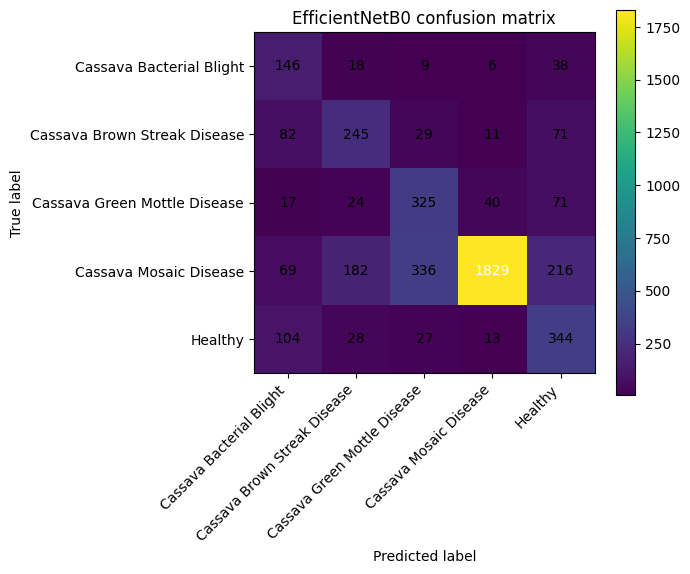

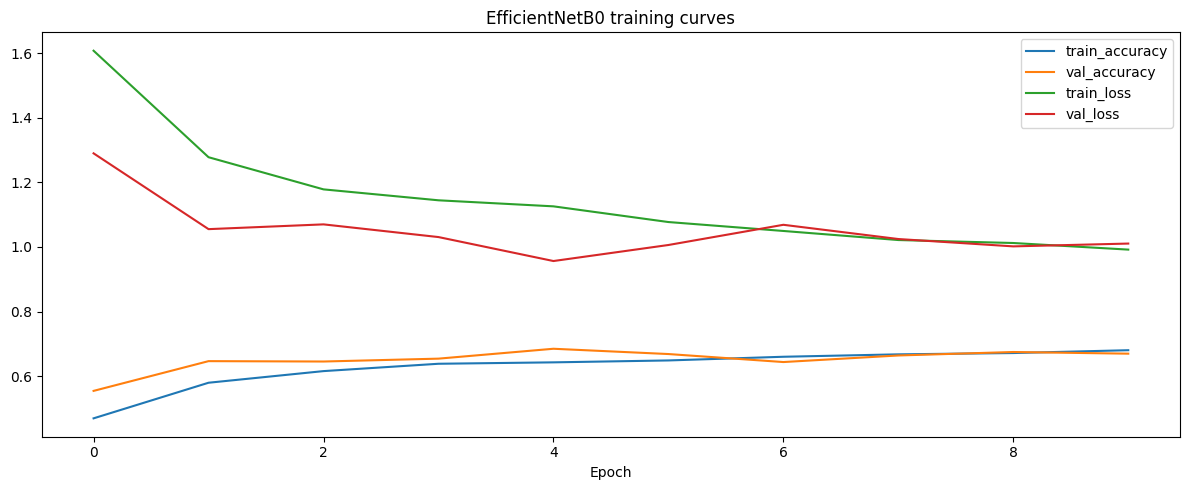

,model_name,val_accuracy,val_f1_macro,params,img_size,batch_size,n_dense_layers,fine_tune_last_n
0,ResNet50,0.694626,0.596737,24181381,224,32,2,40
4,EfficientNetB0,0.675000,0.575864,4446632,224,32,2,40
1,MobileNetV2,0.647196,0.566713,2655045,224,32,2,40
2,DenseNet121,0.603271,0.515524,7369029,224,32,2,40
3,InceptionV3,0.563318,0.481723,22396453,224,32,2,40


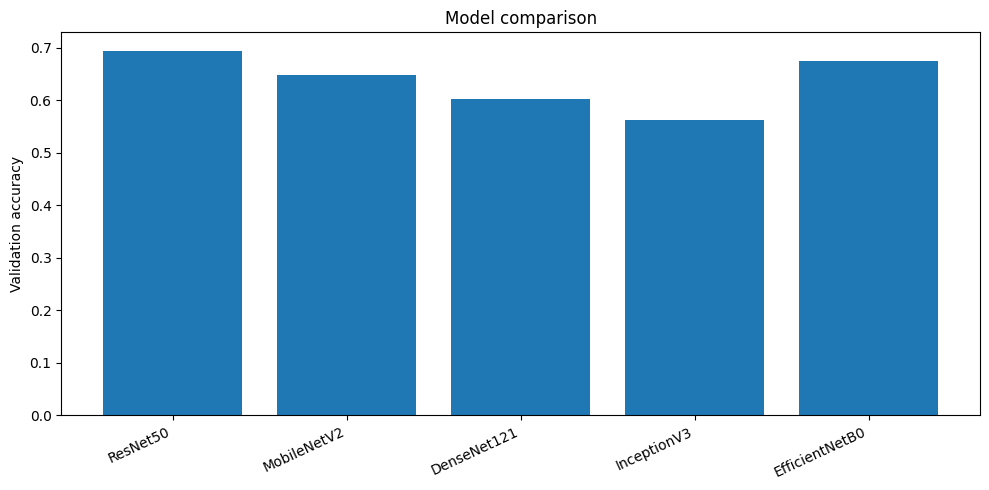

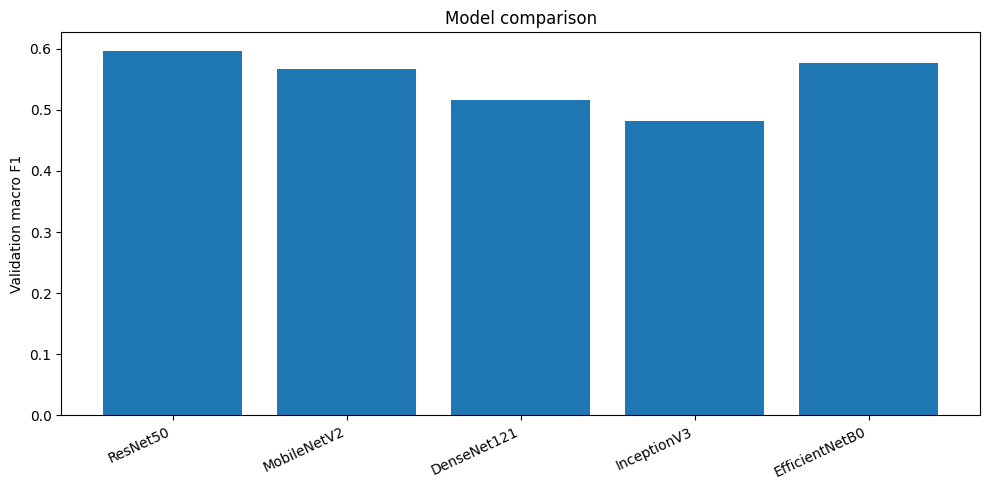

In [37]:
# ============================================================
# 12) Run all 5 transfer learning models
# ============================================================
RUN_TRANSFER_MODELS = True
results = []

if RUN_TRANSFER_MODELS:
    for backbone in ["ResNet50", "MobileNetV2", "DenseNet121", "InceptionV3", "EfficientNetB0"]:
        tf.keras.backend.clear_session()
        gc.collect()

        # A reasonable default head: 2 dense layers.
        out = train_two_stage_model(
            backbone_name=backbone,
            n_dense_layers=2,
            dense_units=256,
            dropout=0.4,
            frozen_epochs=5,
            finetune_epochs=5,
            fine_tune_last_n=40
        )
        results.append(out)

results_df = pd.DataFrame([{
    "model_name": r["model_name"],
    "val_accuracy": r["val_accuracy"],
    "val_f1_macro": r["val_f1_macro"],
    "params": r["params"],
    "img_size": r["img_size"],
    "batch_size": r["batch_size"],
    "n_dense_layers": r["n_dense_layers"],
    "fine_tune_last_n": r["fine_tune_last_n"]
} for r in results])

display(results_df.sort_values("val_f1_macro", ascending=False))

# Plot comparison
if not results_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(results_df["model_name"], results_df["val_accuracy"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Validation accuracy")
    plt.title("Model comparison")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(results_df["model_name"], results_df["val_f1_macro"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Validation macro F1")
    plt.title("Model comparison")
    plt.tight_layout()
    plt.show()
def plot_history_separate(history_dict, model_name):
    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_accuracy.png")
    plt.show()

    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{model_name}_loss.png")
    plt.show()

In [38]:
# ============================================================
# 13) Head-depth ablation on the best backbone
#     This is the part you use to justify why you chose 2 layers, not 1 or 3.
# ============================================================
RUN_HEAD_ABLATION = True

def run_head_ablation(best_backbone="EfficientNetB0", dense_layer_choices=(1, 2, 3)):
    spec = MODEL_SPECS[best_backbone]
    img_size = spec["img_size"]
    batch_size = spec["batch_size"]

    train_ds = make_dataset(train_df, img_size, batch_size=batch_size, training=True)
    val_ds = make_dataset(val_df, img_size, batch_size=batch_size, training=False)

    ablation_rows = []

    for n_dense in dense_layer_choices:
        tf.keras.backend.clear_session()
        gc.collect()

        model, base_model = build_transfer_model(
            backbone_name=best_backbone,
            img_size=img_size,
            n_dense_layers=n_dense,
            dense_units=256,
            dropout=0.4
        )

        compile_model(model, lr=1e-3)
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=4,
            class_weight=CLASS_WEIGHT,
            verbose=1
        )

        unfreeze_last_n_layers(base_model, 40)
        freeze_all_bn(base_model)
        compile_model(model, lr=1e-5)
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=3,
            class_weight=CLASS_WEIGHT,
            verbose=1
        )

        val_probs = model.predict(val_ds, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)
        y_true = val_df["label"].values

        ablation_rows.append({
            "backbone": best_backbone,
            "n_dense_layers": n_dense,
            "val_accuracy": accuracy_score(y_true, val_pred),
            "val_f1_macro": f1_score(y_true, val_pred, average="macro"),
            "params": model.count_params()
        })

    return pd.DataFrame(ablation_rows)

if RUN_HEAD_ABLATION:
    head_ablation_df = run_head_ablation(best_backbone="EfficientNetB0", dense_layer_choices=(1, 2, 3))
    display(head_ablation_df.sort_values("val_f1_macro", ascending=False))


Epoch 1/4


E0000 00:00:1777589666.054409      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.4753 - loss: 1.6531 - val_accuracy: 0.6070 - val_loss: 1.1753
Epoch 2/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.6107 - loss: 1.1590 - val_accuracy: 0.5886 - val_loss: 1.2017
Epoch 3/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.6511 - loss: 1.0912 - val_accuracy: 0.6727 - val_loss: 0.9574
Epoch 4/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 126ms/step - accuracy: 0.6585 - loss: 1.0704 - val_accuracy: 0.6577 - val_loss: 1.0441
Epoch 1/3


E0000 00:00:1777589952.154516      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.6672 - loss: 1.0365 - val_accuracy: 0.6561 - val_loss: 1.0183
Epoch 2/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 128ms/step - accuracy: 0.6804 - loss: 0.9857 - val_accuracy: 0.6675 - val_loss: 0.9819
Epoch 3/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6792 - loss: 0.9848 - val_accuracy: 0.6764 - val_loss: 0.9654
Epoch 1/4


...

E0000 00:00:1777590720.872025      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.3709 - loss: 1.9562 - val_accuracy: 0.5308 - val_loss: 1.3621
Epoch 2/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.5328 - loss: 1.3693 - val_accuracy: 0.5928 - val_loss: 1.2114
Epoch 3/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.5997 - loss: 1.2294 - val_accuracy: 0.6315 - val_loss: 1.1128
Epoch 4/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 128ms/step - accuracy: 0.6019 - loss: 1.2138 - val_accuracy: 0.6266 - val_loss: 1.1253
Epoch 1/3


E0000 00:00:1777591009.354090      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 84s 131ms/step - accuracy: 0.6494 - loss: 1.1308 - val_accuracy: 0.6540 - val_loss: 1.0392
Epoch 2/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 126ms/step - accuracy: 0.6528 - loss: 1.1074 - val_accuracy: 0.6547 - val_loss: 1.0378
Epoch 3/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 126ms/step - accuracy: 0.6695 - loss: 1.0732 - val_accuracy: 0.6509 - val_loss: 1.0664


,backbone,n_dense_layers,val_accuracy,val_f1_macro,params
1,EfficientNetB0,2,0.684346,0.585202,4446632
0,EfficientNetB0,1,0.676402,0.579593,4379816
2,EfficientNetB0,3,0.650935,0.554361,4513448


In [39]:
# ============================================================
# 14) Fine-tuning-depth ablation on the best backbone
#     This is the part you use to justify why you fine-tuned 40 layers,
#     not 20 or 80.
# ============================================================
RUN_FINE_TUNE_ABLATION = True

def run_finetune_ablation(best_backbone="EfficientNetB0", fine_tune_choices=(20, 40, 80)):
    spec = MODEL_SPECS[best_backbone]
    img_size = spec["img_size"]
    batch_size = spec["batch_size"]

    train_ds = make_dataset(train_df, img_size, batch_size=batch_size, training=True)
    val_ds = make_dataset(val_df, img_size, batch_size=batch_size, training=False)

    rows = []
    for n_layers in fine_tune_choices:
        tf.keras.backend.clear_session()
        gc.collect()

        model, base_model = build_transfer_model(
            backbone_name=best_backbone,
            img_size=img_size,
            n_dense_layers=2,
            dense_units=256,
            dropout=0.4
        )

        # stage 1
        compile_model(model, lr=1e-3)
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=4,
            class_weight=CLASS_WEIGHT,
            verbose=1
        )

        # stage 2
        unfreeze_last_n_layers(base_model, n_layers)
        freeze_all_bn(base_model)
        compile_model(model, lr=1e-5)
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=3,
            class_weight=CLASS_WEIGHT,
            verbose=1
        )

        val_probs = model.predict(val_ds, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)
        y_true = val_df["label"].values

        rows.append({
            "backbone": best_backbone,
            "fine_tune_last_n": n_layers,
            "val_accuracy": accuracy_score(y_true, val_pred),
            "val_f1_macro": f1_score(y_true, val_pred, average="macro"),
            "params": model.count_params()
        })

    return pd.DataFrame(rows)

if RUN_FINE_TUNE_ABLATION:
    ft_ablation_df = run_finetune_ablation(best_backbone="EfficientNetB0", fine_tune_choices=(20, 40, 80))
    display(ft_ablation_df.sort_values("val_f1_macro", ascending=False))


Epoch 1/4


E0000 00:00:1777591260.859652      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 79s 128ms/step - accuracy: 0.4264 - loss: 1.7633 - val_accuracy: 0.5502 - val_loss: 1.3201
Epoch 2/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.5676 - loss: 1.3148 - val_accuracy: 0.5643 - val_loss: 1.2805
Epoch 3/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6119 - loss: 1.1973 - val_accuracy: 0.6626 - val_loss: 1.0268
Epoch 4/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 125ms/step - accuracy: 0.6350 - loss: 1.1343 - val_accuracy: 0.6668 - val_loss: 1.0143
Epoch 1/3


E0000 00:00:1777591544.108735      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.6410 - loss: 1.1196 - val_accuracy: 0.6549 - val_loss: 1.0430
Epoch 2/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6606 - loss: 1.0664 - val_accuracy: 0.6558 - val_loss: 1.0369
Epoch 3/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 127ms/step - accuracy: 0.6556 - loss: 1.0739 - val_accuracy: 0.6701 - val_loss: 1.0125
Epoch 1/4


...

E0000 00:00:1777592325.330228      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.4481 - loss: 1.7509 - val_accuracy: 0.5701 - val_loss: 1.3136
Epoch 2/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 125ms/step - accuracy: 0.5664 - loss: 1.2932 - val_accuracy: 0.5624 - val_loss: 1.2633
Epoch 3/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 125ms/step - accuracy: 0.6043 - loss: 1.1810 - val_accuracy: 0.6414 - val_loss: 1.0394
Epoch 4/4
535/535 ━━━━━━━━━━━━━━━━━━━━ 67s 125ms/step - accuracy: 0.6158 - loss: 1.1634 - val_accuracy: 0.6299 - val_loss: 1.1102
Epoch 1/3


E0000 00:00:1777592610.057209      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


535/535 ━━━━━━━━━━━━━━━━━━━━ 89s 138ms/step - accuracy: 0.6647 - loss: 1.0713 - val_accuracy: 0.6769 - val_loss: 0.9597
Epoch 2/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 71s 132ms/step - accuracy: 0.6690 - loss: 1.0330 - val_accuracy: 0.6981 - val_loss: 0.9183
Epoch 3/3
535/535 ━━━━━━━━━━━━━━━━━━━━ 71s 133ms/step - accuracy: 0.6870 - loss: 0.9852 - val_accuracy: 0.6671 - val_loss: 0.9746


,backbone,fine_tune_last_n,val_accuracy,val_f1_macro,params
2,EfficientNetB0,80,0.667056,0.570165,4446632
0,EfficientNetB0,20,0.670093,0.566494,4446632
1,EfficientNetB0,40,0.659112,0.557909,4446632


In [40]:
# ============================================================
# 15) Select best model from the transfer-learning experiments
# ============================================================
if not results_df.empty:
    best_row = results_df.sort_values("val_f1_macro", ascending=False).iloc[0]
    best_model_name = best_row["model_name"]
    print("Best model:", best_model_name)

Best model: ResNet50


In [44]:
# ============================================================
# 16) Optional final training on all labeled data
#     Use this after picking the best architecture.
# ============================================================
RUN_FINAL_TRAINING_ON_FULL_DATA = False

def build_full_train_dataframe(df_all):
    return df_all.reset_index(drop=True).copy()

if RUN_FINAL_TRAINING_ON_FULL_DATA and not results_df.empty:
    best_spec = MODEL_SPECS[best_model_name]
    img_size = best_spec["img_size"]
    batch_size = best_spec["batch_size"]

    full_df = build_full_train_dataframe(df)
    full_ds = make_dataset(full_df, img_size, batch_size=batch_size, training=True)

    model, base_model = build_transfer_model(
        backbone_name=best_model_name,
        img_size=img_size,
        n_dense_layers=2,
        dense_units=256,
        dropout=0.4
    )

    # Use a single training run on all labeled data after architecture selection
    compile_model(model, lr=1e-3)
    model.fit(
        full_ds,
        epochs=5,
        class_weight=CLASS_WEIGHT,
        verbose=1
    )

    unfreeze_last_n_layers(base_model, 40)
    freeze_all_bn(base_model)
    compile_model(model, lr=1e-5)
    model.fit(
        full_ds,
        epochs=3,
        class_weight=CLASS_WEIGHT,
        verbose=1
    )

    model.save(os.path.join(WORK_DIR, "models", f"final_{best_model_name}.keras"))


In [46]:
# ============================================================
# 17) Create submission file
# ============================================================
if not results_df.empty:
    best_spec = MODEL_SPECS[best_model_name]
    img_size = best_spec["img_size"]
    batch_size = best_spec["batch_size"]

    test_df = pd.read_csv(TEST_CSV)
    # sample_submission has image_id and label columns
    # test_df["filepath"] = test_df["image_id"].apply(lambda x: os.path.join(TEST_IMG_DIR, f"{x}.jpg"))
    test_df["filepath"] = test_df["image_id"].apply(
    lambda x: os.path.join(TEST_IMG_DIR, x)
)

    # Rebuild the best model and load the best stage-2 weights from the saved checkpoint
    best_model, best_base = build_transfer_model(
        backbone_name=best_model_name,
        img_size=img_size,
        n_dense_layers=2,
        dense_units=256,
        dropout=0.4
    )
    compile_model(best_model, lr=1e-5)

    stage2_ckpt = os.path.join(WORK_DIR, "models", f"{best_model_name}_stage2.weights.h5")
    if os.path.exists(stage2_ckpt):
        best_model.load_weights(stage2_ckpt)

    test_ds = make_test_dataset(test_df, img_size, batch_size=batch_size)
    test_probs = best_model.predict(test_ds, verbose=0)
    test_pred = np.argmax(test_probs, axis=1)

    submission = pd.read_csv(TEST_CSV)
    submission["label"] = test_pred
    submission_path = os.path.join(WORK_DIR, f"submission_{best_model_name}.csv")
    submission.to_csv(submission_path, index=False)

    print("Saved:", submission_path)
    print(submission.head())

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved: /kaggle/working/submission_ResNet50.csv
         image_id  label
0  2216849948.jpg      2


In [47]:
# ============================================================
# 18) Save a clean results summary
# ============================================================
if not results_df.empty:
    results_path = os.path.join(WORK_DIR, "transfer_learning_results.csv")
    results_df.to_csv(results_path, index=False)
    print("Saved results summary:", results_path)

Saved results summary: /kaggle/working/transfer_learning_results.csv
